In [2]:
import cv2
import numpy as np


In [3]:
img = np.zeros((400, 400, 3), dtype=np.uint8)
img.fill(255)

# Vẽ hình vuông
cv2.rectangle(img, (50, 50), (200, 200), (0, 0, 0), 2)

# Vẽ tam giác
pts = np.array([[300, 50], [250, 150], [350, 150]], np.int32)
cv2.polylines(img, [pts], True, (0, 0, 0), 2)

# Vẽ ngũ giác
pentagon = []
for i in range(5):
    angle = i * 2 * np.pi / 5
    x = int(150 + 80 * np.cos(angle))
    y = int(300 + 80 * np.sin(angle))
    pentagon.append([x, y])
pentagon = np.array(pentagon, np.int32)
cv2.polylines(img, [pentagon], True, (0, 0, 0), 2)

# Lưu ảnh
cv2.imwrite('polygon.jpg', img)
print("Đã tạo ảnh test: polygon.jpg")


Đã tạo ảnh test: polygon.jpg


In [15]:
from google.colab.patches import cv2_imshow

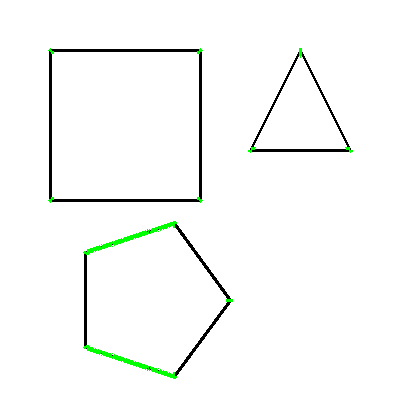

In [25]:
image = cv2.imread('polygon.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
corners = cv2.cornerHarris(gray, 3, 3, 0.04)
image[corners > 0.01 * corners.max()] = [0, 255, 0]
cv2_imshow( image)  # Hiển thị ảnh
cv2.waitKey(0)                        # Chờ phím bấm
cv2.destroyAllWindows()


Phát hiện 266 corners
Kết quả phát hiện corners:


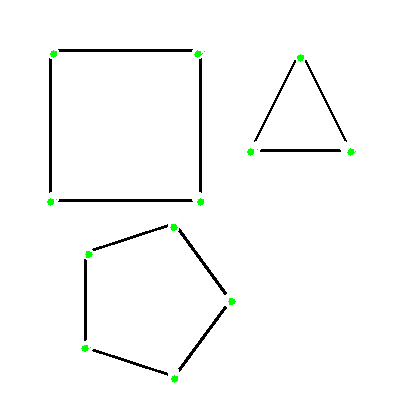

Đã lưu kết quả: /content/drive/MyDrive/result_corners.jpg


In [24]:
import cv2
import numpy as np
from google.colab import drive
from google.colab.patches import cv2_imshow

def detect_corners(image_path):
    """Phát hiện corners với error handling"""

    # Đọc ảnh
    image = cv2.imread(image_path)
    if image is None:
        print(f"Không thể đọc ảnh: {image_path}")
        return None

    # Chuyển sang grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Harris Corner Detection
    corners = cv2.cornerHarris(gray, 3, 5, 0.04)

    # Tìm và vẽ corners dạng điểm tròn
    result = image.copy()
    corner_coords = np.where(corners > 0.01 * corners.max())

    print(f"Phát hiện {len(corner_coords[0])} corners")

    # Vẽ từng corner
    for y, x in zip(corner_coords[0], corner_coords[1]):
        cv2.circle(result, (x, y), 3, (0, 255, 0), -1)  # Điểm xanh
        cv2.circle(result, (x, y), 5, (255, 255, 255), 1)  # Viền trắng

    return result

# Sử dụng với đường dẫn cụ thể
if __name__ == "__main__":

    # Thay đổi đường dẫn này theo vị trí file của bạn
    image_path = '/content/polygon.jpg'  # Sửa tên file ở đây

    result = detect_corners(image_path)

    if result is not None:
        print("Kết quả phát hiện corners:")
        cv2_imshow(result)

        # Lưu kết quả
        output_path = '/content/drive/MyDrive/result_corners.jpg'
        cv2.imwrite(output_path, result)
        print(f"Đã lưu kết quả: {output_path}")
